# Combined Accuracy Figure

Loads diff_acc data from each user study (saved when generating individual figures) and plots all three side-by-side with the same styling.

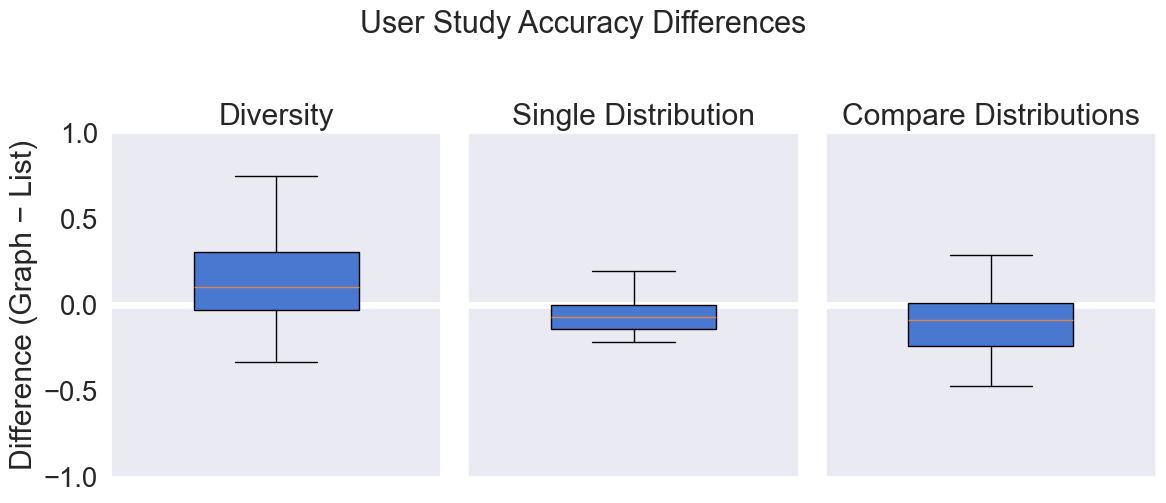

Saved to /Users/emilyreif/Documents/github/llm-consistency-vis/latex/figures/combined_diff_accuracy_by_participant.png


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve paths: run from repo root or user_study_results/combined_post_survey/
root = Path('.').resolve()
for _ in range(6):
    if (root / 'user_study_results' / 'combined').exists():
        break
    root = root.parent

combined_dir = root / 'user_study_results' / 'combined'
out_dir = root / 'latex' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

# Load data from each study (saved when individual notebooks run)
# Try user_study_results/combined/ first, then study-specific combined/ dirs
def find_json(fname):
    candidates = [
        combined_dir / fname,
        root / 'user_study_results' / 'single_distribution' / 'combined' / fname,
        root / 'user_study_results' / 'diversity' / 'combined' / fname,
        root / 'user_study_results' / 'compare_distributions' / 'combined' / fname,
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

datasets = []
for name, fname in [
    ('Diversity', 'diff_diversity.json'),
    ('Single Distribution', 'diff_single_distribution.json'),
    ('Compare Distributions', 'diff_compare_distributions.json'),
]:
    path = find_json(fname)
    if path is not None:
        with open(path) as f:
            data = json.load(f)
        datasets.append((name, np.array(data['diff_acc'])))
    else:
        print(f"Warning: {path} not found")

if len(datasets) < 3:
    print("Need all 3 JSON files. Run single_distribution, diversity, and compare_distributions notebooks first.")
else:
    # Plot side-by-side, same styling as individual figures
    sns.set_theme(style='dark', font_scale=1.8)
    plt.rcParams['font.size'] = 18
    fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
    
    for ax, (title, diff_acc) in zip(axes, datasets):
        bp = ax.boxplot([diff_acc], patch_artist=True, widths=0.5)
        bp['boxes'][0].set_facecolor(sns.color_palette('muted')[0])
        np.random.seed(42)
        jitter = np.random.uniform(-0.12, 0.12, len(diff_acc))
        # ax.scatter(1 + jitter, diff_acc, alpha=0.6, s=50, color='white', zorder=5)
        ax.axhline(0, color='white', linestyle='-', linewidth=5, alpha=1, zorder=1)
        ax.set_ylim(-1, 1)
        ax.set_xticklabels([''])
        ax.set_ylabel('Difference (Graph − List)')
        ax.set_title(title)
    
    for ax in axes[1:]:
        ax.set_ylabel('')
    
    fig.suptitle('User Study Accuracy Differences', fontsize=22, y=1.02)
    plt.tight_layout()
    plt.savefig(out_dir / 'combined_diff_accuracy_by_participant.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {out_dir / 'combined_diff_accuracy_by_participant.png'}")